In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Stellar Classification

In astronomy, stellar classification is the classification of stars based on their spectral characteristics. The classification scheme of galaxies, quasars, and stars is one of the most fundamental in astronomy. The early cataloguing of stars and their distribution in the sky has led to the understanding that they make up our own galaxy and, following the distinction that Andromeda was a separate galaxy to our own, numerous galaxies began to be surveyed as more powerful telescopes were built. This project aims to classify stars, galaxies, and quasars based on their spectral characteristics.

## About the Data

This dataset is from Kaggle.

Classification of Stars, Galaxies and Quasars. Sloan Digital Sky Survey DR17

The data released by the SDSS is under public domain. Its taken from the current data release RD17.

https://www.kaggle.com/datasets/fedesoriano/stellar-classification-dataset-sdss17

| Variable      | Description                                                                                                                               |
| ------------- | ----------------------------------------------------------------------------------------------------------------------------------------- |
| `obj_ID`      | Object Identifier, the unique value that identifies the object in the image catalog used by the CAS                                       |
| `alpha`       | Right Ascension angle at the J2000 epoch                                                                                                  |
| `delta`       | Declination angle at the J2000 epoch                                                                                                      |
| `u`           | Ultraviolet filter in the photometric system                                                                                              |
| `g`           | Green filter in the photometric system                                                                                                    |
| `r`           | Red filter in the photometric system                                                                                                      |
| `i`           | Near Infrared filter in the photometric system                                                                                            |
| `z`           | Infrared filter in the photometric system                                                                                                 |
| `run_ID`      | Run Number used to identify the specific scan                                                                                             |
| `rerun_ID`    | Rerun Number used to specify how the image was processed                                                                                  |
| `cam_col`     | Camera column used to identify the scanline within the run                                                                                |
| `field_ID`    | Field number used to identify each field                                                                                                  |
| `spec_obj_ID` | Unique ID used for optical spectroscopic objects. Two different observations with the same `spec_obj_ID` must share the same output class |
| `class`       | Object class, such as galaxy, star, or quasar                                                                                             |
| `redshift`    | Redshift value based on the increase in wavelength                                                                                        |
| `plate`       | Plate ID used to identify each plate in SDSS                                                                                              |
| `MJD`         | Modified Julian Date, used to indicate when a given piece of SDSS data was taken                                                          |
| `fiber_ID`    | Fiber ID that identifies the fiber that pointed the light at the focal plane in each observation                                          |


In [4]:
df = pd.read_csv("star_classification.csv")

In [5]:
df.describe()

,obj_ID,alpha,delta,u,g,r,i,z,run_ID,rerun_ID,cam_col,field_ID,spec_obj_ID,redshift,plate,MJD,fiber_ID
count,1.000000e+05,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.0,100000.000000,100000.000000,1.000000e+05,100000.000000,100000.000000,100000.000000,100000.000000
mean,1.237665e+18,177.629117,24.135305,21.980468,20.531387,19.645762,19.084854,18.668810,4481.366060,301.0,3.511610,186.130520,5.783882e+18,0.576661,5137.009660,55588.647500,449.312740
std,8.438560e+12,96.502241,19.644665,31.769291,31.750292,1.854760,1.757895,31.728152,1964.764593,0.0,1.586912,149.011073,3.324016e+18,0.730707,2952.303351,1808.484233,272.498404
min,1.237646e+18,0.005528,-18.785328,-9999.000000,-9999.000000,9.822070,9.469903,-9999.000000,109.000000,301.0,1.000000,11.000000,2.995191e+17,-0.009971,266.000000,51608.000000,1.000000
25%,1.237659e+18,127.518222,5.146771,20.352353,18.965230,18.135828,17.732285,17.460677,3187.000000,301.0,2.000000,82.000000,2.844138e+18,0.054517,2526.000000,54234.000000,221.000000
50%,1.237663e+18,180.900700,23.645922,22.179135,21.099835,20.125290,19.405145,19.004595,4188.000000,301.0,4.000000,146.000000,5.614883e+18,0.424173,4987.000000,55868.500000,433.000000
75%,1.237668e+18,233.895005,39.901550,23.687440,22.123767,21.044785,20.396495,19.921120,5326.000000,301.0,5.000000,241.000000,8.332144e+18,0.704154,7400.250000,56777.000000,645.000000
max,1.237681e+18,359.999810,83.000519,32.781390,31.602240,29.571860,32.141470,29.383740,8162.000000,301.0,6.000000,989.000000,1.412694e+19,7.011245,12547.000000,58932.000000,1000.000000


In [6]:
df.isnull().sum()

obj_ID         0
alpha          0
delta          0
u              0
g              0
r              0
i              0
z              0
run_ID         0
rerun_ID       0
cam_col        0
field_ID       0
spec_obj_ID    0
class          0
redshift       0
plate          0
MJD            0
fiber_ID       0
dtype: int64

In [7]:
df.columns

Index(['obj_ID', 'alpha', 'delta', 'u', 'g', 'r', 'i', 'z', 'run_ID',
       'rerun_ID', 'cam_col', 'field_ID', 'spec_obj_ID', 'class', 'redshift',
       'plate', 'MJD', 'fiber_ID'],
      dtype='str')

In [8]:
df['class'].value_counts()

class
GALAXY    59445
STAR      21594
QSO       18961
Name: count, dtype: int64

## Exploring the Data

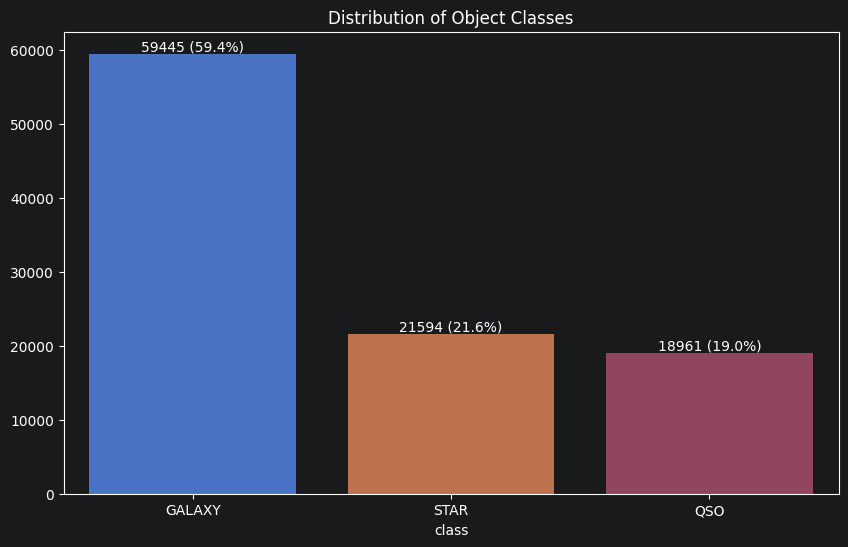

In [9]:
plt.figure(figsize=(10, 6))

data = df['class'].value_counts()
total = data.sum()

ax = sns.barplot(x = data.index, y = data.values, hue = data.index)

for i, value in enumerate(data.values):
    plt.text(i, value, f'{value} ({value / total:.1%})', ha='center', va='bottom')

plt.title('Distribution of Object Classes')

plt.show()

The **Distribution of Object Classes** graph shows that the dataset is not evenly balanced across the three classes. **GALAXY** is the most common class with 59,445 observations, representing about 59.4% of the dataset. **STAR** has 21,594 observations, or about 21.6%, while **QSO** has 18,961 observations, or about 19.0%. This means galaxies make up more than half of the dataset, while stars and quasars appear much less often. Because of this class imbalance, a machine learning model may be more likely to predict the majority class unless the imbalance is considered during training and evaluation.

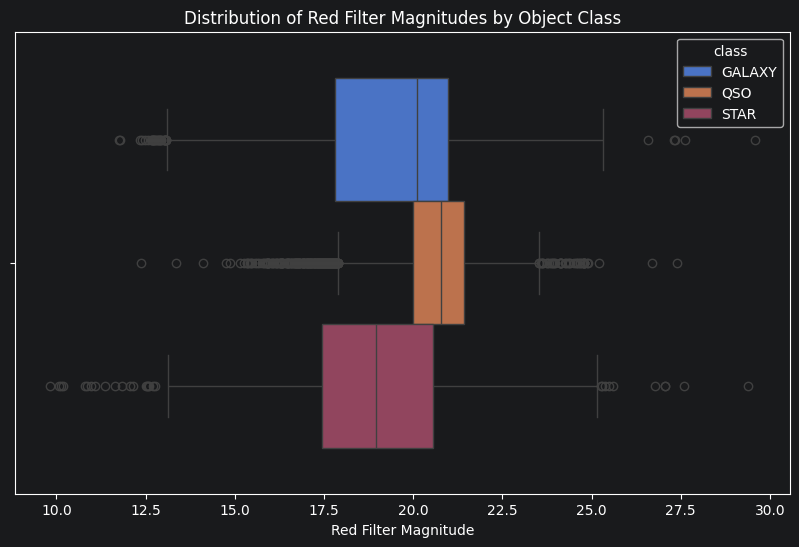

In [10]:
plt.figure(figsize=(10, 6))

sns.boxplot(data = df, x = 'r', hue = 'class')

plt.title('Distribution of Red Filter Magnitudes by Object Class')
plt.xlabel('Red Filter Magnitude')

plt.show()

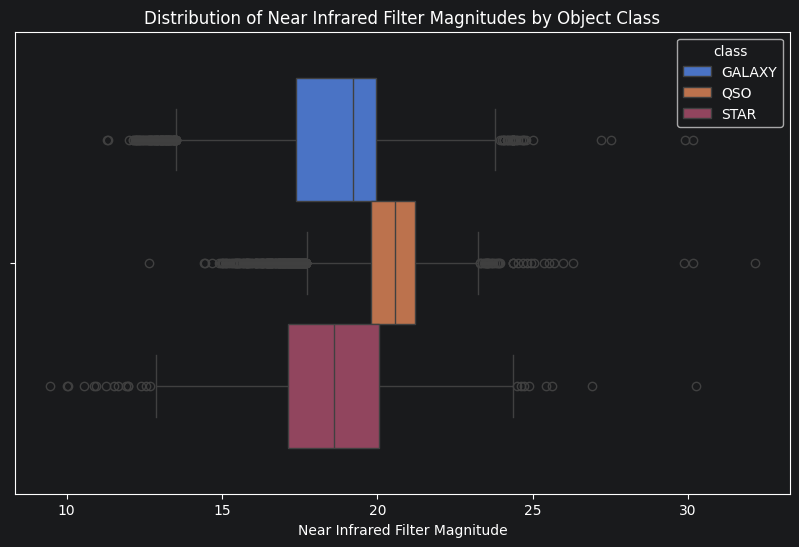

In [11]:
plt.figure(figsize=(10, 6))

sns.boxplot(data = df, x = 'i', hue = 'class')

plt.title('Distribution of Near Infrared Filter Magnitudes by Object Class')
plt.xlabel('Near Infrared Filter Magnitude')

plt.show()

The **Distribution of Near Infrared Filter Magnitudes by Object Class** graph compares the `i` filter magnitude values for galaxies, stars, and quasars. The `i` filter represents near infrared light. As with the other magnitude columns, lower magnitude values usually mean the object appears brighter, while higher magnitude values mean the object appears dimmer.

Based on the box plot, **STAR** objects have the lowest median `i` magnitude, around 18.59, so stars tend to appear brighter in the near infrared filter. **GALAXY** objects have a median around 19.22, placing them slightly dimmer than stars but still brighter than quasars. **QSO** objects have the highest median value, around 20.58, meaning quasars tend to appear dimmer in this filter compared with the other two classes.

The spread of the boxes shows that stars and galaxies have wider ranges of `i` filter magnitudes, which means their near infrared brightness varies more across the dataset. QSOs have a tighter distribution, so most QSO values are more concentrated near the median. This suggests the `i` filter may be especially useful for identifying QSO objects because their values are grouped more consistently and are generally higher than the other classes.

There is still overlap between the three classes, especially between stars and galaxies, so the `i` filter alone would not be enough to classify every object correctly. However, the different medians, spreads, and outliers show that this feature provides useful information for separating galaxies, stars, and quasars when combined with the other filter columns.

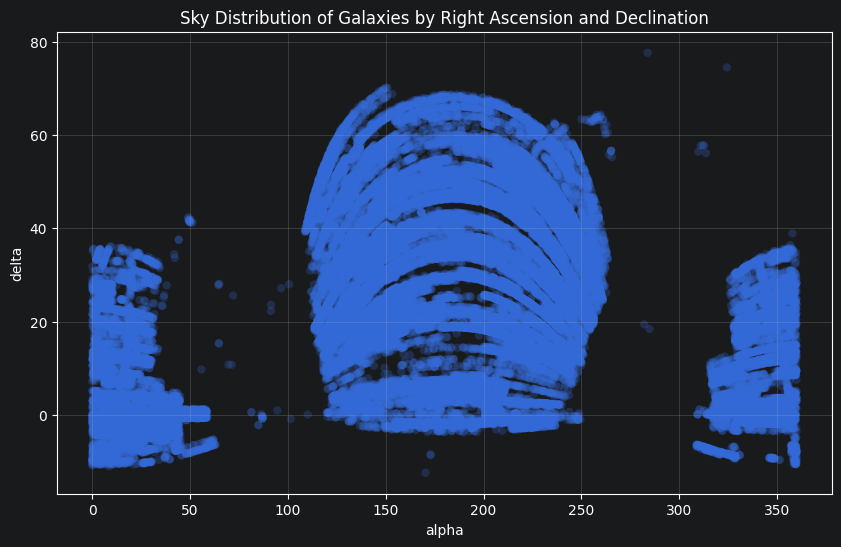

In [12]:
plt.figure(figsize=(10, 6))

sns.scatterplot(data = df[df['class'] == "GALAXY"], x = 'alpha', y = 'delta', alpha = 0.25, edgecolor = 'none')
plt.title('Sky Distribution of Galaxies by Right Ascension and Declination')
plt.grid(True, alpha=0.3)
plt.show()

The **Sky Distribution of Galaxies by Right Ascension and Declination** graph shows the sky positions of objects classified as **GALAXY** in the dataset. The x-axis represents `alpha`, or Right Ascension, which measures the object's horizontal position in the sky from 0 to 360 degrees. The y-axis represents `delta`, or Declination, which measures the object's vertical position in the sky.

The galaxies are not spread evenly across the graph. Instead, they appear in several large curved bands and clustered regions. The densest concentration is between about `alpha = 120` and `260`, with `delta` values mostly between `0` and `70`. There are also smaller groups of galaxies near the left side of the graph around `alpha = 0` to `50`, and another group on the right side around `alpha = 320` to `360`.

The curved shapes are likely caused by how the Sloan Digital Sky Survey scanned different sections of the sky. This means the pattern does not necessarily show the true shape of galaxy distribution in space, but rather the areas of the sky that were observed by the survey. Overall, the graph shows that most galaxy observations in this dataset come from specific surveyed regions instead of being uniformly distributed across all sky coordinates.

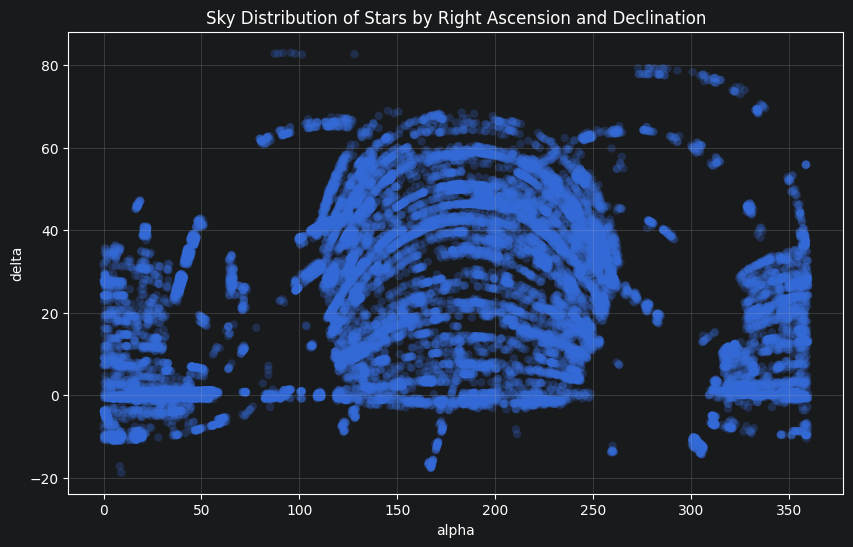

In [13]:
plt.figure(figsize=(10, 6))

sns.scatterplot(data = df[df['class'] == "STAR"], x = 'alpha', y = 'delta', alpha = 0.25, edgecolor = 'none')
plt.title('Sky Distribution of Stars by Right Ascension and Declination')
plt.grid(True, alpha=0.3)
plt.show()

The **Sky Distribution of Stars by Right Ascension and Declination** graph shows the sky positions of objects classified as **STAR** in the dataset. The x-axis represents `alpha`, or Right Ascension, which measures the object's horizontal position in the sky from 0 to 360 degrees. The y-axis represents `delta`, or Declination, which measures the object's vertical position in the sky.

The stars cover nearly the full range of Right Ascension, from about `alpha = 0` to `360`, and a Declination range from about `delta = -18.8` to `83.0`. Like the galaxy graph, the points are not evenly spread across the entire plot. Instead, they follow curved bands and grouped scan regions, with the largest concentration appearing in the middle of the graph between about `alpha = 120` and `260`.

This pattern suggests that the star observations are strongly influenced by the areas of the sky covered by the Sloan Digital Sky Survey. The graph is useful for seeing where the observed stars are located, but it should not be interpreted as a complete map of all stars in the sky. Overall, the star positions show that the dataset contains many observations from specific survey regions, with fewer observations in the gaps between those regions.

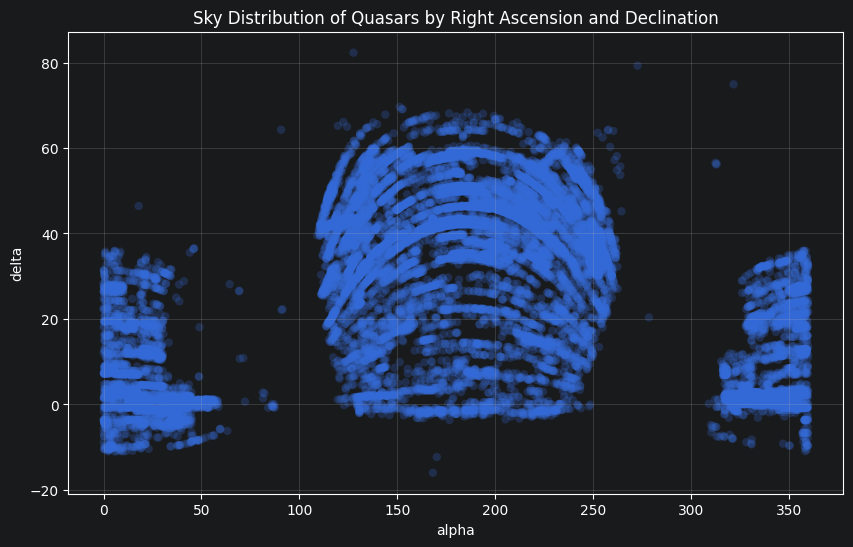

In [14]:
plt.figure(figsize=(10, 6))

sns.scatterplot(data = df[df['class'] == "QSO"], x = 'alpha', y = 'delta', alpha = 0.25, edgecolor = 'none')
plt.title('Sky Distribution of Quasars by Right Ascension and Declination')
plt.grid(True, alpha=0.3)
plt.show()

The **Sky Distribution of Quasars by Right Ascension and Declination** graph shows the sky positions of objects classified as **QSO**, or quasars, in the dataset. The x-axis represents `alpha`, or Right Ascension, which measures the object's horizontal position in the sky from 0 to 360 degrees. The y-axis represents `delta`, or Declination, which measures the object's vertical position in the sky.

The quasars also cover almost the full Right Ascension range, from about `alpha = 0` to `360`, with Declination values ranging from about `delta = -16.0` to `82.3`. The points form similar curved bands and clusters instead of a smooth, even distribution. The most visible concentration is again in the central region of the graph, especially between about `alpha = 120` and `260`, with additional smaller groups near the far left and far right sides.

The repeated curved pattern across the galaxy, star, and quasar graphs shows that these shapes are mostly caused by the survey coverage rather than by the physical shape of the objects' distribution in space. Since QSOs are the least common class among the three visualized groups, this graph may appear less dense than the galaxy graph. Overall, the quasar plot shows that QSO observations are concentrated in the same surveyed sky regions, which means location features like `alpha` and `delta` may partly reflect the survey design.

## Data Cleaning

In [15]:
cleaned_df = df.copy()

### Dropping Values

In [16]:
cleaned_df = cleaned_df[(cleaned_df['u'] != -9999) & (cleaned_df['g'] != -9999) & (cleaned_df['z'] != -9999)]

### Dropping Columns

In [17]:
cleaned_df = cleaned_df.drop(columns=['obj_ID', 'spec_obj_ID', 'run_ID', 'rerun_ID', 'field_ID', 'plate', 'fiber_ID'])

### Comparing

In [18]:
print(f'Original: {df.shape}\nCleaned: {cleaned_df.shape}')

Original: (100000, 18)
Cleaned: (99999, 11)


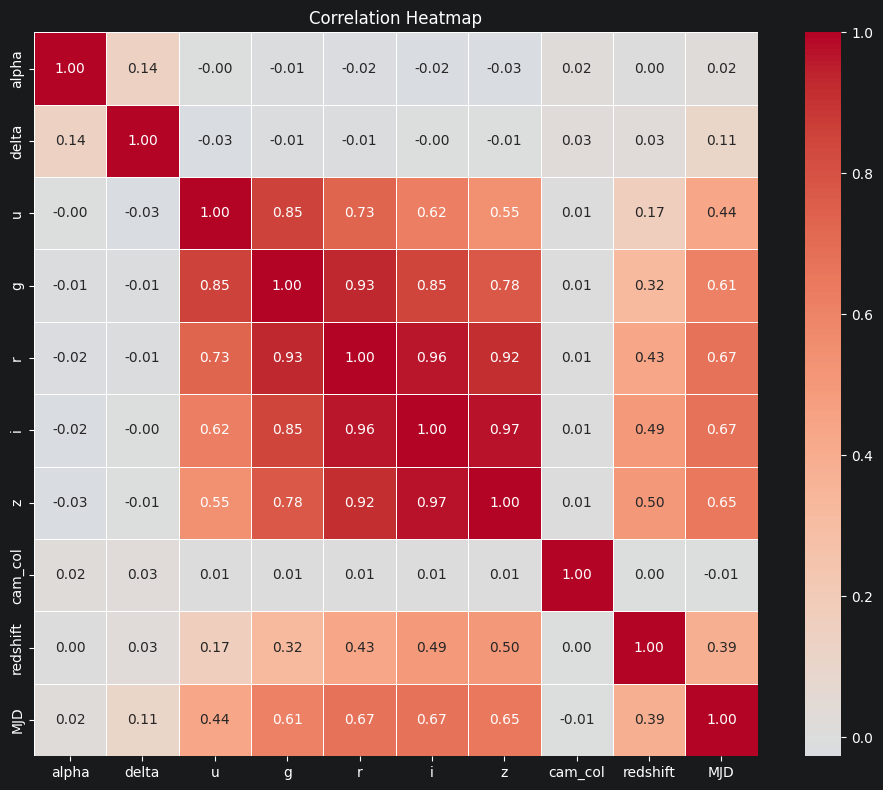

In [19]:
corr_matrix = cleaned_df.corr(numeric_only=True)

plt.figure(figsize=(10,8))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5
)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

The **Correlation Heatmap** shows the relationships between the numeric variables in the cleaned dataset. Values closer to `1.00` mean two variables have a strong positive relationship, values closer to `-1.00` mean they have a strong negative relationship, and values near `0.00` mean there is little or no linear relationship.

The strongest relationships appear between the light filter variables: `u`, `g`, `r`, `i`, and `z`. This makes sense because these columns all measure brightness through different filters, so objects that are bright or dim in one filter often show similar behavior in nearby filters. The strongest filter correlations are between `r`, `i`, and `z`, meaning the red and infrared measurements are closely related.

`redshift` has a moderate positive relationship with some of the filter values, especially `r`, `i`, and `z`. This suggests that redshift may be useful for classification because it connects to how the object's light is measured across different wavelengths.

The position variables, `alpha` and `delta`, do not show strong correlations with most brightness variables. This means an object's location in the sky is mostly separate from its measured brightness and redshift values.

Some ID-related columns may show correlations, but those are less meaningful for classification because they are mainly identifiers or survey tracking values rather than physical measurements of the object.

## Train Test Split and Pre-Processing

In [32]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder

### Train Test Split

In [26]:
X = cleaned_df.drop(columns=['class'])
y = cleaned_df['class']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train size:", len(X_train), f'---> {np.round(100*len(X_train)/(len(X_train)+len(X_test)))}%')
print("y_train size:", len(y_train), f'---> {np.round(100*len(y_train)/(len(y_train)+len(y_test)))}%')
print("\nX_test size:", len(X_test), f'---> {np.round(100*len(X_test)/(len(X_train)+len(X_test)))}%')
print("y_test size:", len(y_test), f'---> {np.round(100*len(y_test)/(len(y_train)+len(y_test)))}%')

print("\nTrain class distribution:")
print(y_train.value_counts(normalize=True).round(3))
print("\nTest class distribution:")
print(y_test.value_counts(normalize=True).round(3))


X_train size: 79999 ---> 80.0%
y_train size: 79999 ---> 80.0%

X_test size: 20000 ---> 20.0%
y_test size: 20000 ---> 20.0%

Train class distribution:
class
GALAXY    0.594
STAR      0.216
QSO       0.190
Name: proportion, dtype: float64

Test class distribution:
class
GALAXY    0.594
STAR      0.216
QSO       0.190
Name: proportion, dtype: float64


### Pre-Processing

#### Feature Engineering
Create color-index features from the photometric filter columns. These differences are often useful for separating stars, galaxies, and quasars.

In [29]:
def add_color_features(data):
    data = data.copy()
    data['u_g'] = data['u'] - data['g']
    data['g_r'] = data['g'] - data['r']
    data['r_i'] = data['r'] - data['i']
    data['i_z'] = data['i'] - data['z']
    return data

X_train_features = add_color_features(X_train)
X_test_features = add_color_features(X_test)

X_train_features[['u_g', 'g_r', 'r_i', 'i_z']].head()

,u_g,g_r,r_i,i_z
31871,2.77671,1.80017,0.67776,0.38179
5421,2.03060,1.00679,0.43334,0.38472
81868,1.09486,0.29782,0.09619,-0.02816
88633,4.18650,1.88650,0.61025,0.29746
16810,1.87346,1.73972,0.77792,0.44137


#### Target Encoding
Convert the class labels into numeric values for models that require encoded targets.

In [30]:
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

encoded_classes = {
    class_name: int(code)
    for class_name, code in zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_))
}

encoded_classes

{'GALAXY': 0, 'QSO': 1, 'STAR': 2}

#### Feature Scaling and Categorical Encoding
Scale continuous numeric features and one-hot encode `cam_col`. The transformer is fit on training data only to avoid test-set leakage.

In [33]:
numeric_features = [
    'alpha', 'delta', 'u', 'g', 'r', 'i', 'z', 'redshift', 'MJD',
    'u_g', 'g_r', 'r_i', 'i_z'
]
categorical_features = ['cam_col']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_features)
    ]
)

preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. `

#### Apply Preprocessing
Fit the preprocessing transformer on the training features, then transform both training and testing features.

In [34]:
X_train_processed = preprocessor.fit_transform(X_train_features)
X_test_processed = preprocessor.transform(X_test_features)

print('Processed training shape:', X_train_processed.shape)
print('Processed testing shape:', X_test_processed.shape)


Processed training shape: (79999, 18)
Processed testing shape: (20000, 18)


#### Modeling Variables to Use
From this point forward, use the processed feature matrices and encoded target arrays for modeling:

- `X_train_processed` for training features
- `X_test_processed` for testing features
- `y_train_encoded` for training labels
- `y_test_encoded` for testing labels

Keep the original `X_train`, `X_test`, `y_train`, and `y_test` only for inspection or interpretation.

## Modeling

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from scipy.stats import loguniform
from sklearn.model_selection import RandomizedSearchCV


### Models

#### Logistic Regression
For this project, Logistic Regression gives a clear starting point for classifying galaxies, stars, and quasars. If more complex models do not improve much beyond this model, then the relationships in the processed features may already be mostly separable with a simpler decision boundary.

In [39]:
lr_pipeline = Pipeline([
    ('lr', LogisticRegression(random_state=42, max_iter=1000))
])

lr_param_grid = [
    {
        'lr__solver': ['lbfgs', 'saga'],
        'lr__C': loguniform(0.001, 10),
        'lr__class_weight': [None, 'balanced']
    }
]

lr_grid = RandomizedSearchCV(
    lr_pipeline,
    lr_param_grid,
    n_iter=10,
    cv=3,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=2,
    random_state=42
)

In [42]:
lr_grid.fit(X_train_processed, y_train_encoded)

Fitting 3 folds for each of 10 candidates, totalling 30 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","[{'lr__C': <scipy.stats....00196CECB1BD0>, 'lr__class_weight': [None, 'balanced'], 'lr__solver': ['lbfgs', 'saga']}]"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1_macro'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchan

#### K-Nearest Neighbors
For this project, KNN is useful because objects with similar brightness values, color-index features, and redshift values may belong to the same astronomical class. Since KNN uses distances between observations, it should use the scaled processed features.

In [47]:
knn_pipeline = Pipeline([
    ('knn', KNeighborsClassifier())
])

knn_param_grid = {
    'knn__n_neighbors': [3, 5, 7, 11, 15, 21],
    'knn__weights': ['uniform', 'distance'],
    'knn__metric': ['euclidean', 'manhattan']
}

knn_grid = RandomizedSearchCV(
    knn_pipeline,
    knn_param_grid,
    n_iter=10,
    cv=3,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=3,
    random_state=42
)


In [49]:
knn_grid.fit(X_train_processed, y_train_encoded)

Fitting 3 folds for each of 10 candidates, totalling 30 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...lassifier())])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'knn__metric': ['euclidean', 'manhattan'], 'knn__n_neighbors': [3, 5, ...], 'knn__weights': ['uniform', 'distance']}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1_macro'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versioncha

#### Random Forest
For this project, Random Forest is useful because the relationship between photometric filters, redshift, position, and object class may not be purely linear. It can also help show which features are most important for distinguishing galaxies, stars, and quasars.

In [45]:
rf_pipeline = Pipeline([
    ('rf', RandomForestClassifier(random_state=42, class_weight='balanced'))
    ])

rf_param_grid = {
    'rf__n_estimators': [100, 200, 300],
    'rf__max_depth': [None, 10, 20],
    'rf__min_samples_split': [2, 5, 10],
    'rf__min_samples_leaf': [1, 2, 4],
    'rf__max_features': ['sqrt', 'log2']
    }

rf_grid = RandomizedSearchCV(
    rf_pipeline,
    rf_param_grid,
    n_iter=10,
    cv=3,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=3
)

In [46]:
rf_grid.fit(X_train_processed, y_train_encoded)

Fitting 3 folds for each of 10 candidates, totalling 30 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'rf__max_depth': [None, 10, ...], 'rf__max_features': ['sqrt', 'log2'], 'rf__min_samples_leaf': [1, 2, ...], 'rf__min_samples_split': [2, 5, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1_macro'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies 

## Metrics

In [50]:
from sklearn.metrics import classification_report

In [53]:
class_metric_results = []
models = {
    "Logistic Regression": lr_grid,
    "K-Nearest Neighbors": knn_grid,
    "Random Forest": rf_grid
}
for model_name, model in models.items():
    y_pred = model.best_estimator_.predict(X_test_processed)

    report = classification_report(
        y_test_encoded,
        y_pred,
        target_names=label_encoder.classes_,
        output_dict=True
    )

    for class_name in label_encoder.classes_:
        class_metric_results.append({
            'Model': model_name,
            'Class': class_name,
            'Precision': report[class_name]['precision'],
            'Recall': report[class_name]['recall'],
            'F1 Score': report[class_name]['f1-score'],
            'Support': report[class_name]['support']
        })

class_metrics_df = pd.DataFrame(class_metric_results)
class_metrics_df


,Model,Class,Precision,Recall,F1 Score,Support
0,Logistic Regression,GALAXY,0.963755,0.966187,0.964970,11889.0
1,Logistic Regression,QSO,0.951800,0.885285,0.917338,3792.0
2,Logistic Regression,STAR,0.948177,0.999768,0.973290,4319.0
3,K-Nearest Neighbors,GALAXY,0.939872,0.962402,0.951004,11889.0
4,K-Nearest Neighbors,QSO,0.952287,0.894778,0.922638,3792.0
5,K-Nearest Neighbors,STAR,0.918133,0.906228,0.912142,4319.0
6,Random Forest,GALAXY,0.979269,0.985365,0.982308,11889.0
7,Random Forest,QSO,0.966476,0.935127,0.950543,3792.0
8,Random Forest,STAR,0.988324,0.999537,0.993899,4319.0


Based on the class-level metrics, **Random Forest is the strongest model overall**. It has the highest F1 score for every class: `GALAXY` (`0.982`), `QSO` (`0.951`), and `STAR` (`0.994`). This means it gives the best balance between correctly identifying each class and avoiding incorrect predictions.

**Logistic Regression** is a strong baseline. It performs very well on `GALAXY` with an F1 score of `0.965` and on `STAR` with an F1 score of `0.973`. However, its `QSO` recall is lower at `0.885`, meaning it misses more true quasars than the other models.

**K-Nearest Neighbors** performs reasonably well, especially for `GALAXY` and `QSO`, but it is the weakest model for `STAR`. Its `STAR` F1 score is `0.912`, which is much lower than Logistic Regression and Random Forest. This suggests that distance-based classification does not separate stars as cleanly in this feature space.

Across all models, **`QSO` is the hardest class to classify** because it has the lowest recall and F1 scores overall. `STAR` is classified extremely well by Logistic Regression and Random Forest, while `GALAXY` is consistently strong across all three models. Based on these results, **Random Forest is the best model to use so far**.

## Feature Importance

### Random Forest

In [58]:
best_rf = rf_grid.best_estimator_.named_steps['rf']

feature_names = preprocessor.get_feature_names_out()
feature_names = [
    name.replace('num__', '').replace('cat__', '')
    for name in feature_names
]

rf_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': best_rf.feature_importances_
})

rf_importance = rf_importance.sort_values(
    by='Importance',
    ascending=False
).reset_index(drop=True)

rf_importance


,Feature,Importance
0,redshift,0.516136
1,r_i,0.107045
2,g_r,0.087761
3,u_g,0.067992
4,z,0.048708
5,i,0.035956
6,i_z,0.033293
7,g,0.027153
8,MJD,0.021567
9,r,0.020307


In [ ]:
plt.figure(figsize=(10, 6))

top15_rf = rf_importance.head(15).copy()
colors = ['steelblue' if v >= 0 else 'salmon' for v in top15_rf['Importance']]

ax = sns.barplot(
    data=top15_rf,
    x='Importance',
    y='Feature',
    hue='Feature',
    palette=dict(zip(top15_rf['Feature'], colors)),
    legend=False
)

ax.axvline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
plt.title('Top 15 Random Forest Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

### Logistic Regression Feature Importance

In [68]:
best_lr = lr_grid.best_estimator_.named_steps['lr']

feature_names = preprocessor.get_feature_names_out()
feature_names = [
    name.replace('num__', '').replace('cat__', '')
    for name in feature_names
]

lr_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': np.abs(best_lr.coef_).mean(axis=0)
})

lr_importance = lr_importance.sort_values(
    by='Importance',
    ascending=False
).reset_index(drop=True)

lr_importance


,Feature,Importance
0,redshift,24.910105
1,g_r,0.335434
2,r_i,0.284548
3,u,0.280764
4,u_g,0.242391
5,MJD,0.188916
6,g,0.171509
7,cam_col_6,0.132192
8,delta,0.129474
9,cam_col_2,0.094386


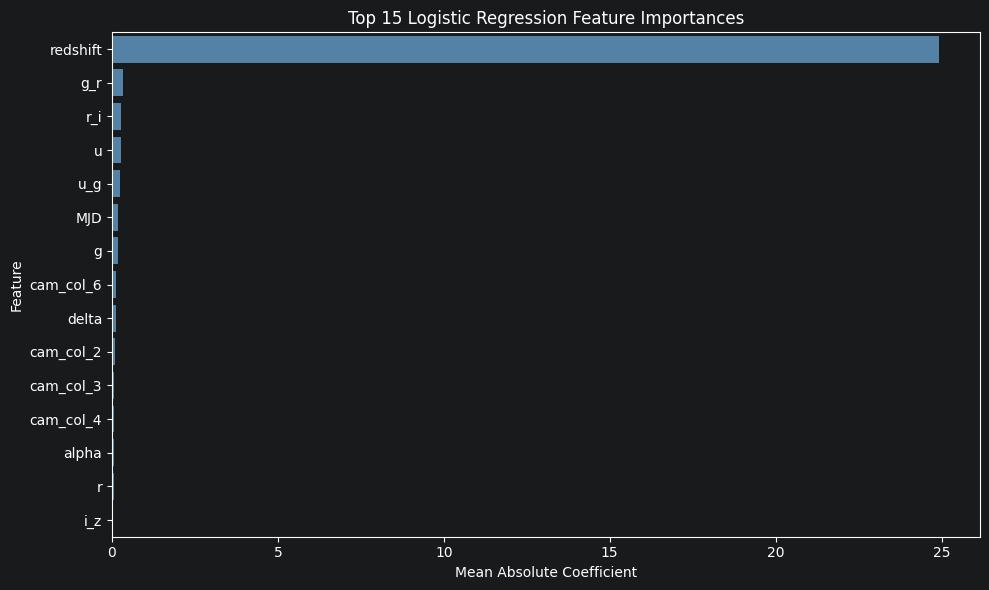

In [81]:
plt.figure(figsize=(10, 6))

top15_lr = lr_importance.head(15).copy()
colors = ['steelblue' if v >= 0 else 'salmon' for v in top15_lr['Importance']]

ax = sns.barplot(
    data=top15_lr,
    x='Importance',
    y='Feature',
    hue='Feature',
    palette=dict(zip(top15_lr['Feature'], colors)),
    legend=False
)

ax.axvline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
plt.title('Top 15 Logistic Regression Feature Importances')
plt.xlabel('Mean Absolute Coefficient')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

### K-Nearest Neighbors Feature Importance

In [82]:
from sklearn.inspection import permutation_importance

knn_sample_size = min(3000, X_test_processed.shape[0])
X_test_knn_sample = X_test_processed[:knn_sample_size]
y_test_knn_sample = y_test_encoded[:knn_sample_size]

knn_permutation = permutation_importance(
    knn_grid.best_estimator_,
    X_test_knn_sample,
    y_test_knn_sample,
    scoring='f1_macro',
    n_repeats=5,
    random_state=42,
    n_jobs=-1
)

knn_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': knn_permutation.importances_mean,
    'Importance Std': knn_permutation.importances_std
})

knn_importance = knn_importance.sort_values(
    by='Importance',
    ascending=False
).reset_index(drop=True)

knn_importance


,Feature,Importance,Importance Std
0,redshift,0.205500,0.010113
1,MJD,0.028149,0.002234
2,alpha,0.011500,0.002185
3,r_i,0.011297,0.001803
4,delta,0.004917,0.002602
5,i_z,0.003219,0.002200
6,u_g,0.003177,0.001509
7,cam_col_6,-0.000325,0.001456
8,cam_col_3,-0.000482,0.001319
9,cam_col_5,-0.000562,0.000734


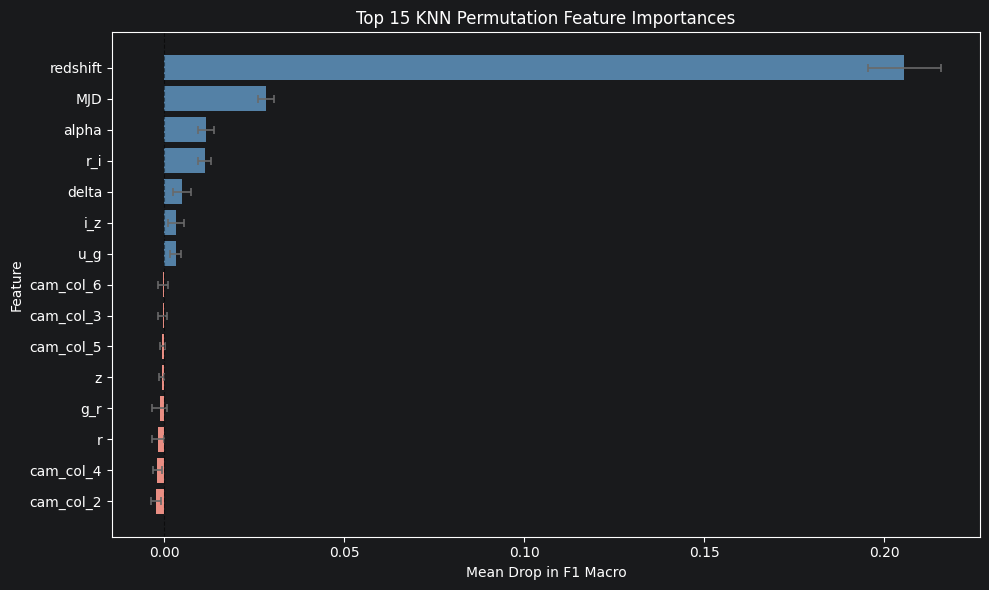

In [79]:
plt.figure(figsize=(10, 6))

top15 = knn_importance.head(15).copy()
colors = ['steelblue' if v >= 0 else 'salmon' for v in top15['Importance']]

ax = sns.barplot(
    data=top15,
    x='Importance',
    y='Feature',
    hue='Feature',
    palette=dict(zip(top15['Feature'], colors)),
    legend=False
)

for i, (_, row) in enumerate(top15.iterrows()):
    ax.errorbar(
        x=row['Importance'],
        y=i,
        xerr=row['Importance Std'],
        fmt='none',
        color='dimgray',
        capsize=3,
        linewidth=1.2,
        capthick=1.2
    )

ax.axvline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
plt.title('Top 15 KNN Permutation Feature Importances')
plt.xlabel('Mean Drop in F1 Macro')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

## ROC AUC CURVE

In [76]:
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.preprocessing import label_binarize

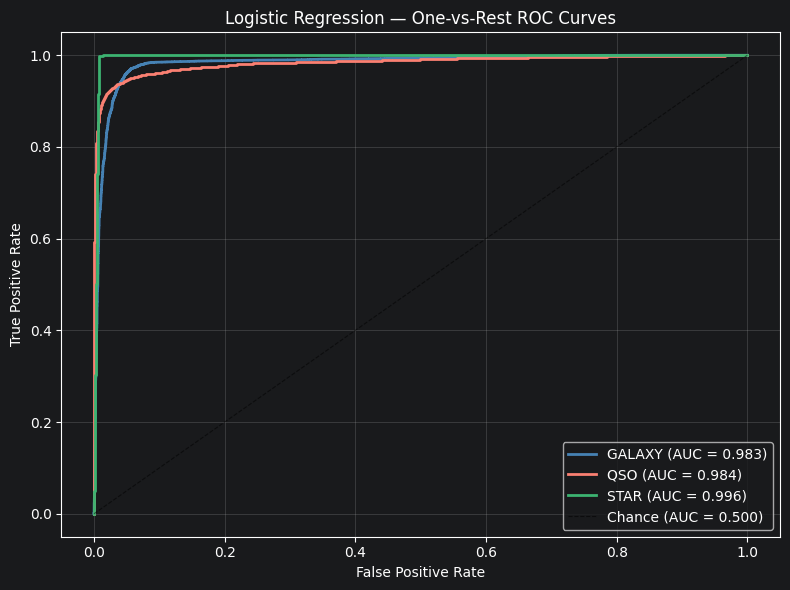

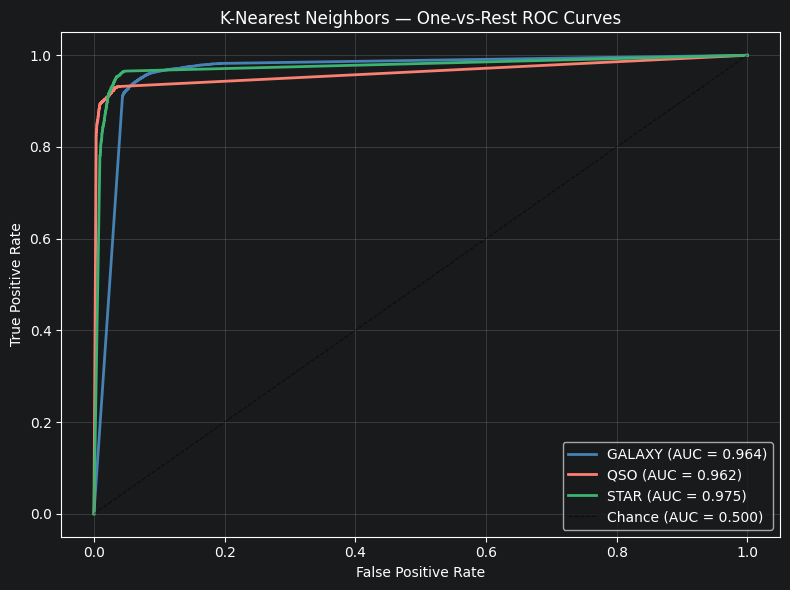

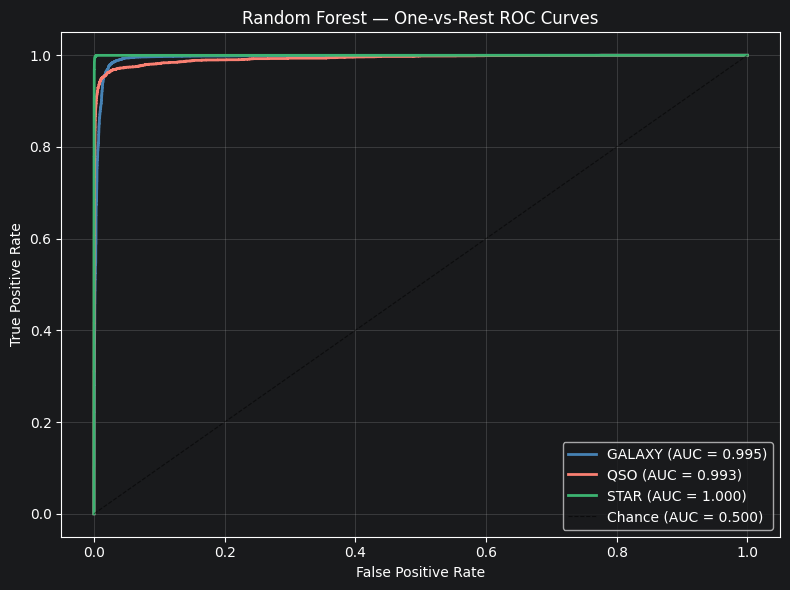

In [83]:
y_test_binarized = label_binarize(
    y_test_encoded,
    classes=range(len(label_encoder.classes_))
)

class_colors = {'GALAXY': 'steelblue', 'QSO': 'salmon', 'STAR': 'mediumseagreen'}

for model_name, model in models.items():
    y_score = model.best_estimator_.predict_proba(X_test_processed)

    plt.figure(figsize=(8, 6))

    for class_index, class_name in enumerate(label_encoder.classes_):
        fpr, tpr, _ = roc_curve(
            y_test_binarized[:, class_index],
            y_score[:, class_index]
        )
        auc_score = roc_auc_score(
            y_test_binarized[:, class_index],
            y_score[:, class_index]
        )

        plt.plot(
            fpr,
            tpr,
            label=f'{class_name} (AUC = {auc_score:.3f})',
            color=class_colors[class_name],
            linewidth=2
        )

    plt.plot([0, 1], [0, 1], linestyle='--', color='black', linewidth=0.8, alpha=0.5, label='Chance (AUC = 0.500)')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'{model_name} — One-vs-Rest ROC Curves')
    plt.legend(loc='lower right')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

### ROC-AUC Graph Interpretations

#### Logistic Regression ROC-AUC
The Logistic Regression ROC-AUC graph shows how well the linear model separates each class from the other two classes using a one-vs-rest approach. A curve closer to the top-left corner means the model is better at identifying that class while keeping false positives low. For this project, Logistic Regression should perform strongly for `GALAXY` and `STAR`, which matches the earlier precision, recall, and F1-score results. The `QSO` curve is expected to be weaker because Logistic Regression had the lowest `QSO` recall among its class-level scores, meaning it missed more true quasars than it missed galaxies or stars. Overall, this graph helps show that Logistic Regression is a useful baseline, but it may not capture all of the nonlinear patterns needed to separate quasars as well as the stronger models.

#### K-Nearest Neighbors ROC-AUC
The K-Nearest Neighbors ROC-AUC graph shows how well KNN separates each class based on distance in the processed feature space. Since KNN depends heavily on feature similarity, the scaling and color-index features are important for this model. The graph should show reasonable separation for `GALAXY` and `QSO`, but the `STAR` curve may be weaker compared with Logistic Regression and Random Forest. This matches the class-level metrics, where KNN had the lowest `STAR` F1 score. If the KNN ROC curves sit farther from the top-left corner than the Random Forest curves, that suggests that distance-based classification is not capturing the class boundaries as effectively for this dataset.

#### Random Forest ROC-AUC
The Random Forest ROC-AUC graph should show the strongest overall class separation. Random Forest had the best F1 scores for `GALAXY`, `QSO`, and `STAR`, so its ROC curves should be closest to the top-left corner across the three classes. This means the model is better at ranking true class examples above non-class examples. The `STAR` curve is expected to be especially strong because Random Forest had nearly perfect `STAR` recall and the highest `STAR` F1 score. The `QSO` curve may still be the lowest of the three classes, but it should be better than the Logistic Regression and KNN `QSO` curves. Overall, the Random Forest ROC-AUC graph supports the conclusion that Random Forest is the best-performing model so far.

In general, ROC-AUC values closer to `1.0` mean stronger classification performance, while values near `0.5` mean the model is close to random guessing. Because this is a multiclass problem, each curve compares one class against the other two classes.